In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import matplotlib.gridspec

In [2]:
file = "FRB20180725A_stokesi_dynamic_spectrum.h5"
data = h5py.File(file, "r")

np.array(data["statistics"])

array(['central_moment_2', 'central_moment_3', 'central_moment_4', 'mean',
       'nsample'], dtype='<U16')

In [3]:
file_name = "FRB20180725A_stokesi_dynamic_spectrum.h5"
dt = 0.9830399940256029

with h5py.File(file_name, "r") as f:
    print(f.keys())
    wfall = f["data"][:]
    good_freq = f["good_freq"][:]
    freqs = f["index_map"]["freqs"][:]
    spec = f["calibration"]["spectrum"][:]
    eventname = "FRB20180725A"

<KeysViewHDF5 ['calibration', 'data', 'flag', 'good_freq', 'index_map', 'model', 'statistics', 'times']>


In [4]:
wfall[~good_freq, :] = np.nan
ts = np.nansum(wfall, axis=0)

def boxcar_kernel(width):
    width = int(round(width, 0))
    return np.ones(width, dtype="float32") / np.sqrt(width)

def find_burst(ts, min_width=1, max_width=128):
    min_width = int(min_width)
    max_width = int(max_width)
    # do not search widths bigger than timeseries
    widths = list(range(min_width, min(max_width + 1, len(ts)-2)))
    # envelope finding
    snrs = np.empty_like(widths, dtype=float)
    peaks = np.empty_like(widths, dtype=int)
    for i in range(len(widths)):
        convolved = scipy.signal.convolve(ts, boxcar_kernel(widths[i]), mode="same")
        peaks[i] = np.nanargmax(convolved)
        snrs[i] = convolved[peaks[i]]
    best_idx = np.nanargmax(snrs)
    return peaks[best_idx], widths[best_idx], snrs[best_idx]

peak, width, snr = find_burst(ts)

/tmp/ipykernel_541392/2708035571.py:9: RuntimeWarning: Mean of empty slice
  return np.nanmean(data[:(n_chan//fbin_factor)*fbin_factor].reshape(-1, fbin_factor, n_time), axis=1)


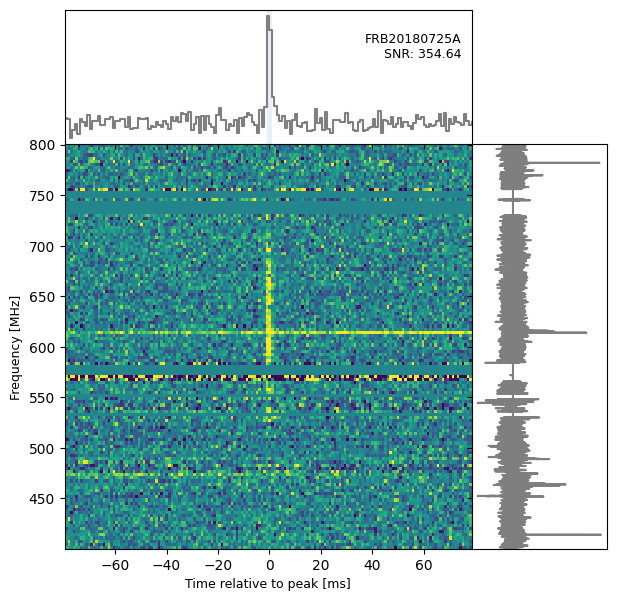

In [5]:
plot_time = (np.arange(len(ts)) - peak) * dt
spec = np.nansum(wfall, axis=1)
plot_freq = np.linspace(freqs[0], freqs[-1], len(spec))

extent = [plot_time.min(), plot_time.max(), freqs[0], freqs[-1]]

def bin_freq_channels(data, fbin_factor=16):
    n_chan, n_time = data.shape
    return np.nanmean(data[:(n_chan//fbin_factor)*fbin_factor].reshape(-1, fbin_factor, n_time), axis=1)

wfall_plot = bin_freq_channels(wfall, 128)
wfall_plot[np.isnan(wfall_plot)] = np.nanmedian(wfall_plot)

fig = plt.figure(figsize=(7, 7))
gs = matplotlib.gridspec.GridSpec(ncols=2, nrows=2, figure=fig, width_ratios=[3, 1],
                                  height_ratios=[1, 3], hspace=0.0, wspace=0.0)

data_im = plt.subplot(gs[2])           
data_ts = plt.subplot(gs[0], sharex=data_im)   
data_spec = plt.subplot(gs[3], sharey=data_im)

cmap = plt.cm.viridis
vmin, vmax = np.nanpercentile(wfall_plot, [1, 99])

data_im.imshow(wfall_plot, aspect="auto", interpolation="none",
               extent=extent, vmin=vmin, vmax=vmax, cmap=cmap, origin='lower')

data_ts.plot(plot_time, ts, color="tab:gray", drawstyle="steps-post")
# Highlight Burst Width
data_ts.axvspan(- (0.5 * width) * dt, (0.5 * width) * dt, 
                facecolor="tab:blue", edgecolor=None, alpha=0.1)

data_spec.plot(spec, plot_freq, color="tab:gray")


plt.setp(data_ts.get_xticklabels(), visible=False)
data_ts.set_yticks([])
plt.setp(data_spec.get_yticklabels(), visible=False)
data_spec.set_xticks([])



# Add Labels
data_im.set_ylabel("Frequency [MHz]", fontsize=9)
data_im.set_xlabel("Time relative to peak [ms]", fontsize=9)

# Add event text info
xlim, ylim = data_ts.get_xlim(), data_ts.get_ylim()
data_ts.text(xlim[1]*0.95, ylim[1]*0.8, 
             f"{eventname}\nSNR: {snr:.2f}", 
             ha="right", va="top", fontsize=9)

plt.show()